<a href="https://colab.research.google.com/github/lukalklikadze/walmart-sales-forecasting/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# ══ Bootstrap ══
!pip -q install mlflow kaggle

!git clone -q https://github.com/lukalklikadze/walmart-sales-forecasting.git /content/repo \
    2>/dev/null || (cd /content/repo && git pull -q)
import sys; sys.path.append("/content/repo")

from src.config import setup_env, DATA_DIR, KAGGLE_COMP
print("MLflow →", setup_env())

import os, glob, zipfile, subprocess
os.makedirs(DATA_DIR, exist_ok=True)
subprocess.run(["kaggle","competitions","download","-c",KAGGLE_COMP,"-p",DATA_DIR,"--force"], check=True)
with zipfile.ZipFile(os.path.join(DATA_DIR, KAGGLE_COMP + ".zip")) as z: z.extractall(DATA_DIR)
for inner in glob.glob(os.path.join(DATA_DIR, "*.csv.zip")):
    with zipfile.ZipFile(inner) as z: z.extractall(DATA_DIR)

from src.data import load_raw
train, test, stores, features = load_raw()
print("train:", train.shape, "| test:", test.shape)

MLflow → https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow
train: (421570, 16) | test: (115064, 15)


In [13]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

EDA_FIGS, EDA_METRICS, EDA_PARAMS = [], {}, {}
def keep(fig, name):      # stash a figure for MLflow logging later
    EDA_FIGS.append((name, fig)); return fig

In [14]:
print("Train:", train.shape, "| Test:", test.shape)
print("Stores:", train.Store.nunique(), "| Depts:", train.Dept.nunique())
print("Store×Dept series:", train.groupby(['Store','Dept']).ngroups)
print("\nColumns:\n", list(train.columns))
train.info()
train.head()

EDA_METRICS['n_stores'] = train.Store.nunique()
EDA_METRICS['n_depts']  = train.Dept.nunique()
EDA_METRICS['n_series'] = train.groupby(['Store','Dept']).ngroups
EDA_METRICS['train_rows'] = len(train)

Train: (421570, 16) | Test: (115064, 15)
Stores: 45 | Depts: 81
Store×Dept series: 3331

Columns:
 ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float

Negative-sales rows: 1285 (0.30%)   <- returns > sales that week
Zero-sales rows:     73
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


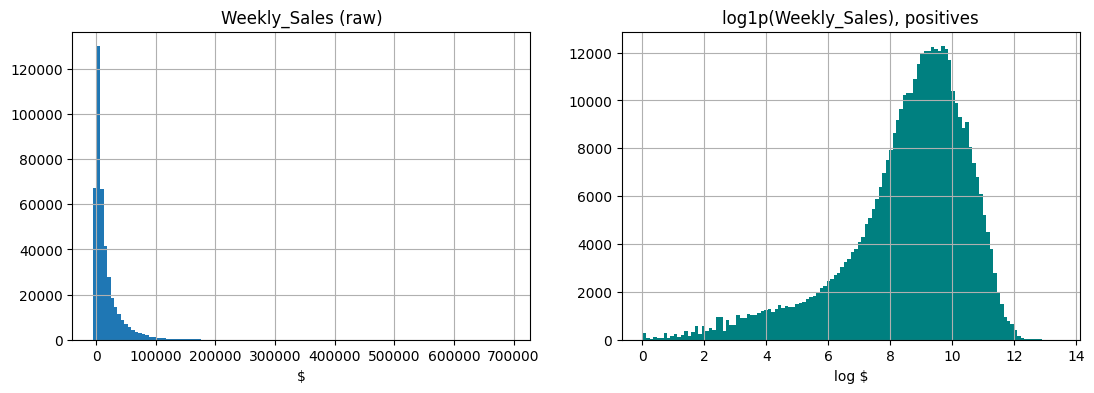

In [15]:
neg  = int((train.Weekly_Sales < 0).sum())
zero = int((train.Weekly_Sales == 0).sum())
print(f"Negative-sales rows: {neg} ({neg/len(train)*100:.2f}%)   <- returns > sales that week")
print(f"Zero-sales rows:     {zero}")
print(train.Weekly_Sales.describe())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(train.Weekly_Sales, bins=120); ax[0].set(title="Weekly_Sales (raw)", xlabel="$")
pos = train.Weekly_Sales[train.Weekly_Sales > 0]
ax[1].hist(np.log1p(pos), bins=120, color='teal'); ax[1].set(title="log1p(Weekly_Sales), positives", xlabel="log $")
keep(fig, "01_target_distribution.png"); plt.show()

EDA_METRICS['neg_sales_rows'] = neg
EDA_METRICS['sales_max'] = float(train.Weekly_Sales.max())

In [16]:
print("Train:", train.Date.min().date(), "→", train.Date.max().date(), f"({train.Date.nunique()} weeks)")
print("Test: ", test.Date.min().date(),  "→", test.Date.max().date(),  f"({test.Date.nunique()} weeks)")
print("Gap train-end → test-start:", (test.Date.min() - train.Date.max()).days, "days")

EDA_PARAMS['train_range'] = f"{train.Date.min().date()}..{train.Date.max().date()}"
EDA_PARAMS['test_range']  = f"{test.Date.min().date()}..{test.Date.max().date()}"

Train: 2010-02-05 → 2012-10-26 (143 weeks)
Test:  2012-11-02 → 2013-07-26 (39 weeks)
Gap train-end → test-start: 7 days


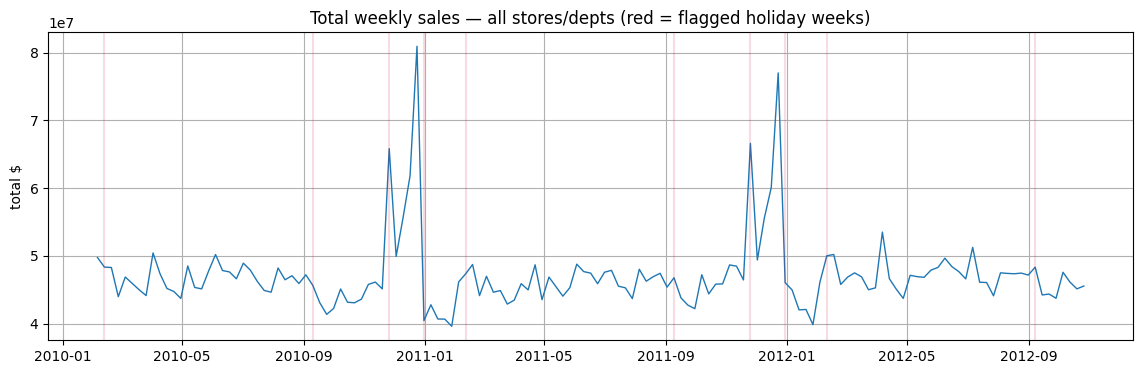

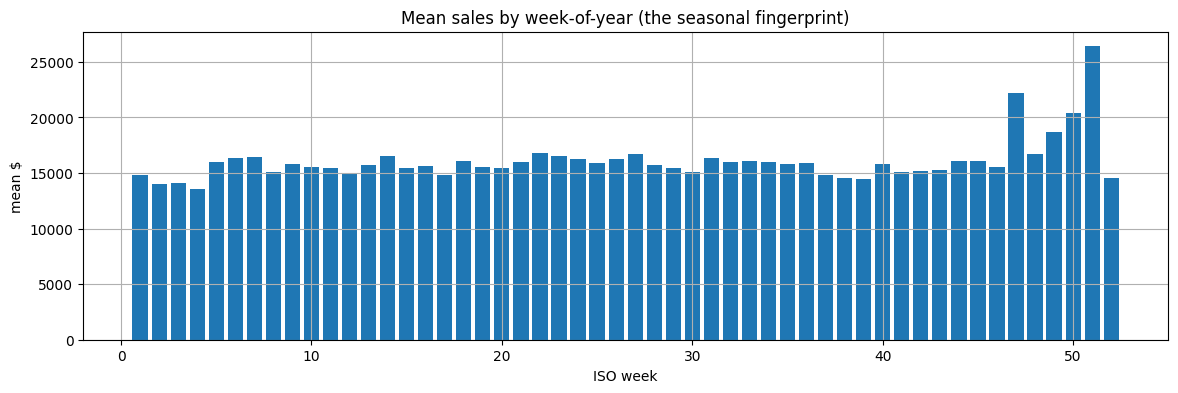

In [17]:
weekly = train.groupby('Date')['Weekly_Sales'].sum()
hol = train.loc[train.IsHoliday, 'Date'].unique()

fig = plt.figure(figsize=(14, 4))
plt.plot(weekly.index, weekly.values, lw=1)
for h in hol: plt.axvline(pd.Timestamp(h), color='crimson', alpha=0.15)
plt.title("Total weekly sales — all stores/depts (red = flagged holiday weeks)"); plt.ylabel("total $")
keep(fig, "02_global_seasonality.png"); plt.show()

train['woy'] = train.Date.dt.isocalendar().week.astype(int)
woy = train.groupby('woy')['Weekly_Sales'].mean()
fig = plt.figure(figsize=(14, 4))
plt.bar(woy.index, woy.values); plt.title("Mean sales by week-of-year (the seasonal fingerprint)")
plt.xlabel("ISO week"); plt.ylabel("mean $")
keep(fig, "03_week_of_year.png"); plt.show()

                   mean   median   count
IsHoliday                               
False      15901.445069  7589.95  391909
True       17035.823187  7947.74   29661
Holiday share of rows: 7.0%

Mean sales by specific holiday:
 holiday_name
Thanksgiving    22220.944538
SuperBowl       16377.996441
None            15901.445069
LaborDay        15881.693339
Christmas       14543.387158
Name: Weekly_Sales, dtype: float64


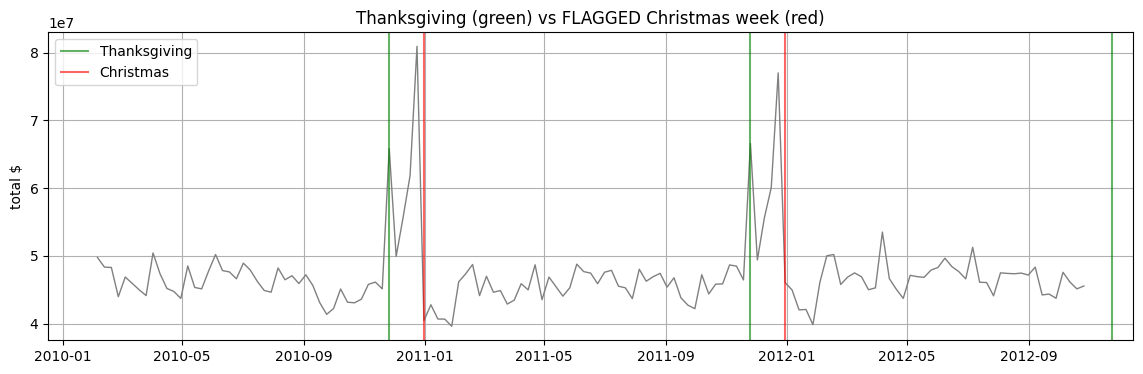

In [18]:
print(train.groupby('IsHoliday')['Weekly_Sales'].agg(['mean','median','count']))
print("Holiday share of rows:", f"{train.IsHoliday.mean()*100:.1f}%")

holiday_dates = {
    'SuperBowl':    ['2010-02-12','2011-02-11','2012-02-10'],
    'LaborDay':     ['2010-09-10','2011-09-09','2012-09-07'],
    'Thanksgiving': ['2010-11-26','2011-11-25','2012-11-23'],
    'Christmas':    ['2010-12-31','2011-12-30'],
}
date2hol = {pd.Timestamp(d): n for n, ds in holiday_dates.items() for d in ds}
train['holiday_name'] = train.Date.map(date2hol).fillna('None')
print("\nMean sales by specific holiday:\n",
      train.groupby('holiday_name')['Weekly_Sales'].mean().sort_values(ascending=False))

fig = plt.figure(figsize=(14, 4))
plt.plot(weekly.index, weekly.values, lw=1, color='gray')
for name, color in [('Thanksgiving','green'), ('Christmas','red')]:
    for i, d in enumerate(holiday_dates[name]):
        plt.axvline(pd.Timestamp(d), color=color, alpha=0.6, label=name if i == 0 else None)
plt.legend(); plt.title("Thanksgiving (green) vs FLAGGED Christmas week (red)"); plt.ylabel("total $")
keep(fig, "04_holiday_timing.png"); plt.show()

EDA_METRICS['holiday_mean']    = float(train.loc[train.IsHoliday, 'Weekly_Sales'].mean())
EDA_METRICS['nonholiday_mean'] = float(train.loc[~train.IsHoliday, 'Weekly_Sales'].mean())

Type
A    22
B    17
C     6
Name: count, dtype: int64
      count           mean    min     max
Type                                     
A        22  177247.727273  39690  219622
B        17  101190.705882  34875  140167
C         6   40541.666667  39690   42988


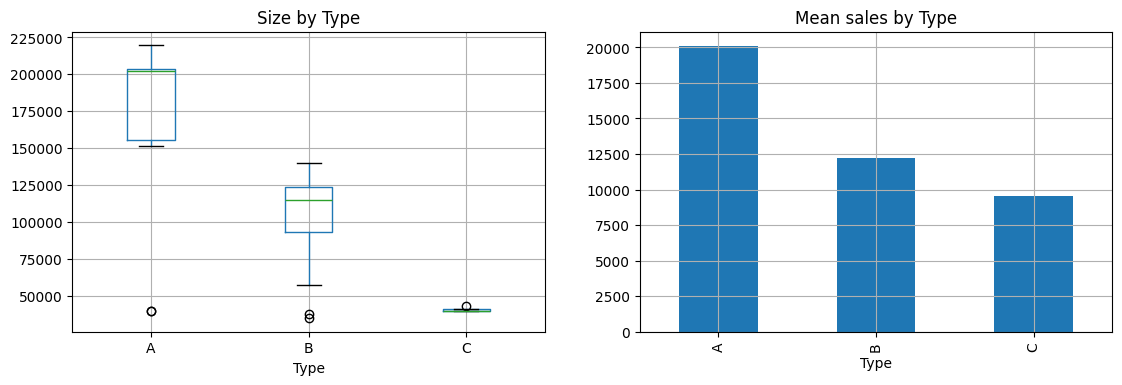

In [19]:
print(stores.Type.value_counts())
print(stores.groupby('Type')['Size'].agg(['count','mean','min','max']))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
stores.boxplot(column='Size', by='Type', ax=ax[0]); ax[0].set_title("Size by Type")
train.groupby('Type')['Weekly_Sales'].mean().plot.bar(ax=ax[1], title="Mean sales by Type")
plt.suptitle(""); keep(fig, "05_store_type_size.png"); plt.show()

Depts: 81


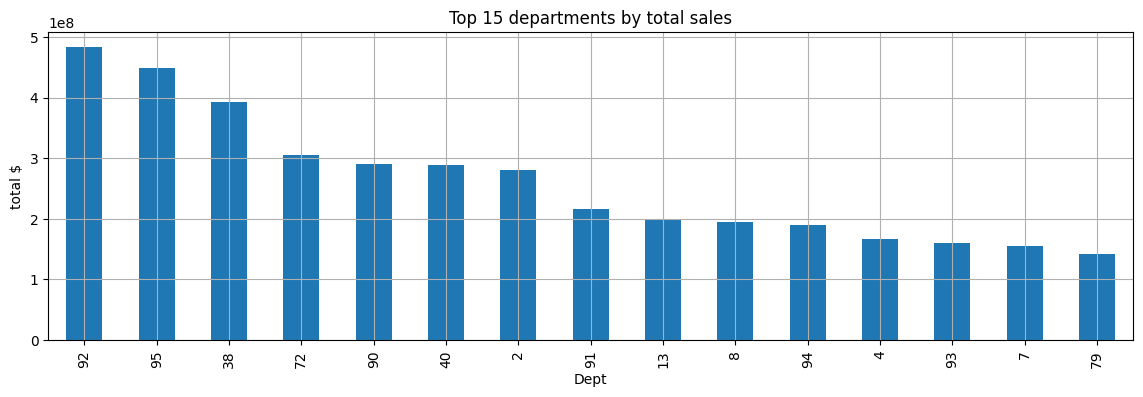

Depts per store: min 61 max 79


In [20]:
print("Depts:", train.Dept.nunique())
top = train.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False).head(15)
fig = plt.figure(figsize=(14, 4))
top.plot.bar(); plt.title("Top 15 departments by total sales"); plt.ylabel("total $")
keep(fig, "06_top_departments.png"); plt.show()

cov = train.groupby('Store')['Dept'].nunique()
print("Depts per store: min", cov.min(), "max", cov.max())

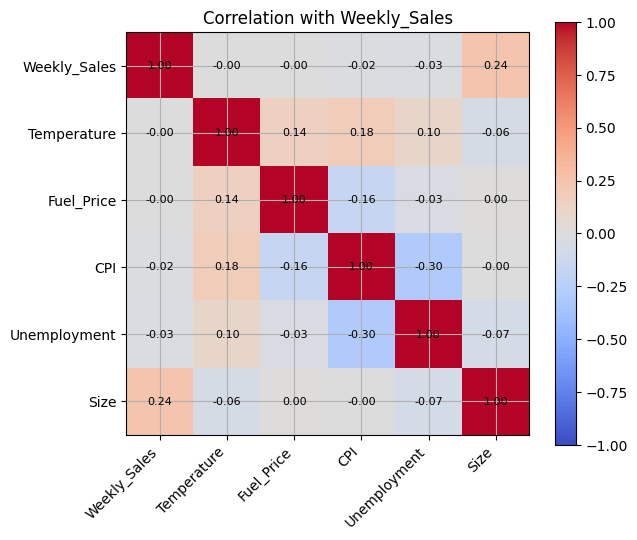

Weekly_Sales    1.000000
Size            0.243828
Fuel_Price     -0.000120
Temperature    -0.002312
CPI            -0.020921
Unemployment   -0.025864
Name: Weekly_Sales, dtype: float64


In [21]:
num = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment','Size']
corr = train[num].corr()

fig = plt.figure(figsize=(6.5, 5.5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1); plt.colorbar()
plt.xticks(range(len(num)), num, rotation=45, ha='right'); plt.yticks(range(len(num)), num)
for i in range(len(num)):
    for j in range(len(num)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=8)
plt.title("Correlation with Weekly_Sales"); keep(fig, "07_correlations.png"); plt.show()
print(corr['Weekly_Sales'].sort_values(ascending=False))

Fraction missing (train):
 MarkDown1    0.642572
MarkDown2    0.736110
MarkDown3    0.674808
MarkDown4    0.679847
MarkDown5    0.640790
dtype: float64


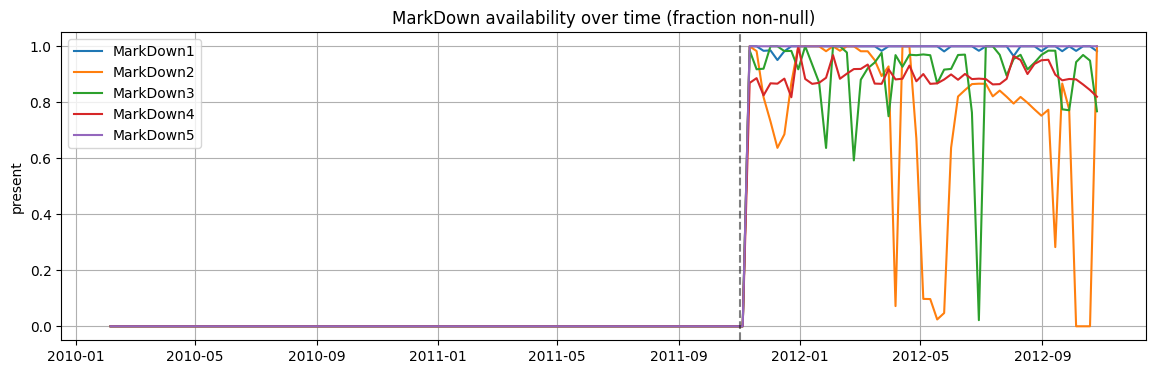

In [22]:
md = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
print("Fraction missing (train):\n", train[md].isna().mean())

avail = train.groupby('Date')[md].apply(lambda d: d.notna().mean())
fig = plt.figure(figsize=(14, 4))
for c in md: plt.plot(avail.index, avail[c], label=c)
plt.axvline(pd.Timestamp('2011-11-01'), color='k', ls='--', alpha=0.5)
plt.legend(); plt.title("MarkDown availability over time (fraction non-null)"); plt.ylabel("present")
keep(fig, "08_markdown_availability.png"); plt.show()

for c in md: EDA_METRICS[f"missing_{c}"] = float(train[c].isna().mean())

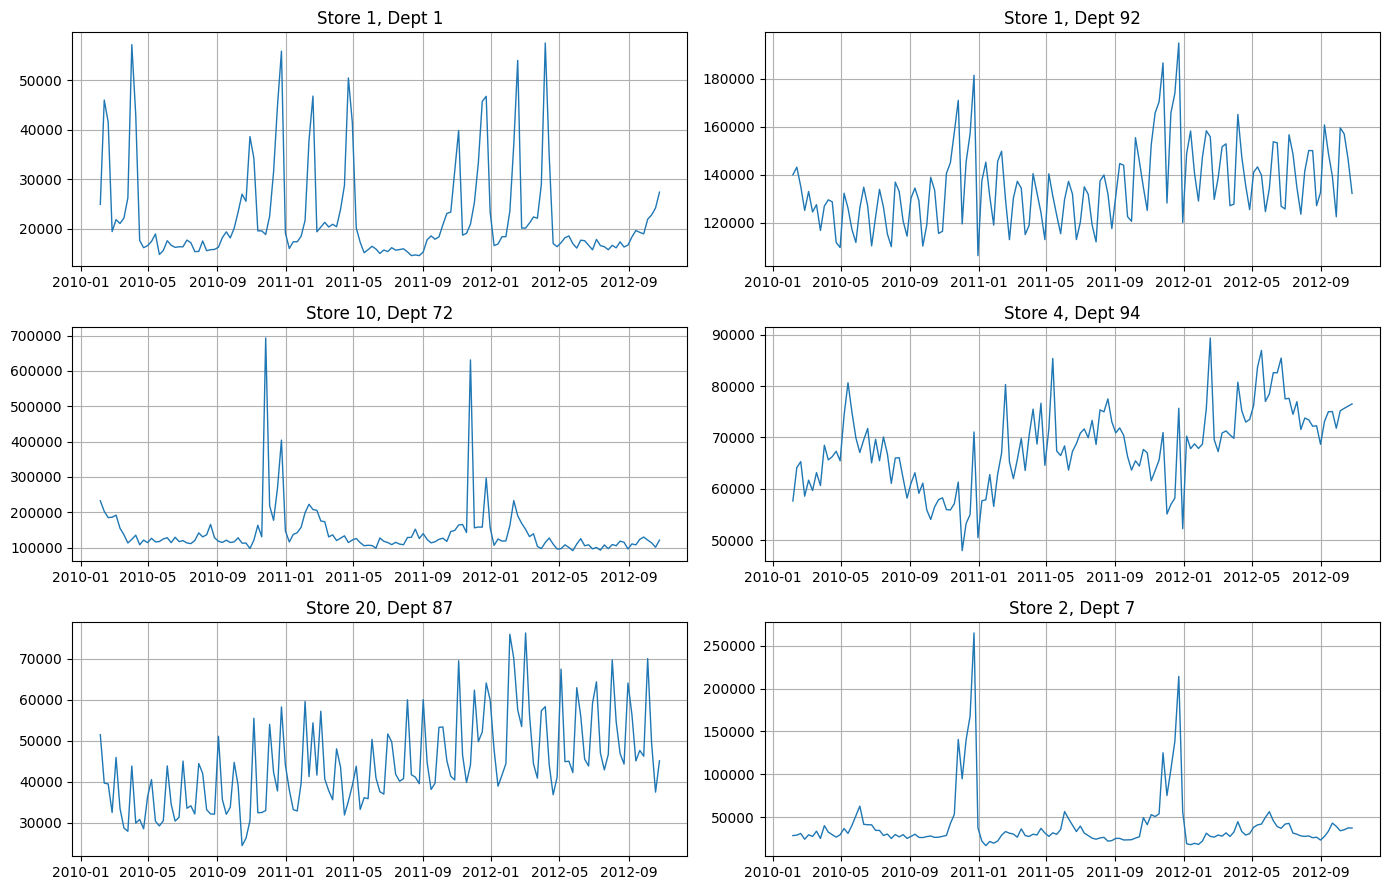

In [23]:
examples = [(1,1),(1,92),(10,72),(4,94),(20,87),(2,7)]
fig, ax = plt.subplots(3, 2, figsize=(14, 9))
for a, (s, d) in zip(ax.ravel(), examples):
    sub = train[(train.Store==s) & (train.Dept==d)].sort_values('Date')
    a.plot(sub.Date, sub.Weekly_Sales, lw=1); a.set_title(f"Store {s}, Dept {d}")
plt.tight_layout(); keep(fig, "09_individual_series.png"); plt.show()

In [24]:
import mlflow
mlflow.set_experiment("EDA")
with mlflow.start_run(run_name="eda_full"):
    mlflow.log_params(EDA_PARAMS)
    mlflow.log_metrics(EDA_METRICS)
    for name, fig in dict(EDA_FIGS).items():   # dict() dedupes if you re-ran cells
        mlflow.log_figure(fig, name)
    mlflow.log_dict({k: (int(v) if isinstance(v, (int, np.integer)) else float(v))
                     for k, v in EDA_METRICS.items()}, "eda_summary.json")
print("EDA logged → open the EDA experiment on DagsHub")

2026/07/07 09:47:02 INFO mlflow.tracking.fluent: Experiment with name 'EDA' does not exist. Creating a new experiment.


🏃 View run eda_full at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/1/runs/1e89d061de754feaa53f0edd0aecb4a2
🧪 View experiment at: https://dagshub.com/llikl23/walmart-sales-forecasting.mlflow/#/experiments/1
EDA logged → open the EDA experiment on DagsHub
